In [1]:

from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI


In [2]:

model = Ollama(model="gemma3:270m")

In [9]:
# define the state:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str 


In [14]:

def create_outline(state: BlogState) -> BlogState:
    
    # extract the title to gen outline
    title = state['title']

    # define the prompt for this 
    prompt = f'generate a details outline for a blog on the topic {title}'

    # call the llm 
    outline= model.invoke(prompt)

    # update the state.
    state['outline'] = outline

    return state

def create_blog(state: BlogState)-> BlogState:
    
    # extract the title and outline
    title = state['title']
    outline = state['outline']

    # define the prompt
    prompt = f'Write a detailed blog on the title {title} by uisng the  following outline\n {outline}'

    # call the llm
    content = model.invoke(prompt)
    state['content'] = content
    return state


In [15]:
# define the StateGraph:

graph = StateGraph(BlogState)

# add node to the graph
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# add edge
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)
# complie graph
workflow = graph.compile()
# execute the graph

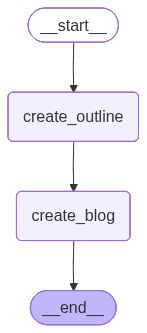

In [16]:
from IPython.display import Image

Image(
    workflow.get_graph().draw_mermaid_png()
)

In [17]:


initial_state = {'title': 'Raise of AI in India'}

final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'Raise of AI in India', 'outline': "Here's a detailed outline for a blog post on the rise of AI in India:\n\n**Blog Post Title:** The Rise of AI in India: Opportunities, Challenges, and Future Trends\n\n**Target Audience:** General public interested in AI, technology enthusiasts, business professionals, and individuals seeking information on the impact of AI in India.\n\n**Overall Goal:** To provide a comprehensive overview of the current state of AI in India, its potential benefits and challenges, and the emerging trends shaping its growth.\n\n**I. Introduction (Hook & Overview)**\n\n*   **A. Thesis Statement:** The rise of AI in India presents a significant opportunity to drive economic growth, improve quality of life, and create new industries. However, it also presents challenges related to ethical considerations, regulatory hurdles, and societal impact.\n*   **B. Overview of AI in India:** Briefly describe the scope of AI in India, highlighting its role in various sector